# Carbon uptake across different La Nina periods

Let's compare the 2010-11 La Nina, with the recent triple La Nina we;ve experienced in that few years

In [1]:
import os
import sys
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from odc.geo.xr import assign_crs
import matplotlib as mpl
from matplotlib.cm import ScalarMappable

In [18]:
from datacube.utils.dask import start_local_dask
client = start_local_dask(mem_safety_margin='2Gb')
client

In [3]:
base = f'/g/data/xc0/project/AusEFlux/'
version='v2.1'
year_end = '2024'

## Open datasets

and reproject to limit data volume

In [4]:
# ----NEE-------------------------------
folder = f'{base}results/AusEFlux/{version}/NEE/'
files = [f'{folder}/{i}' for i in os.listdir(folder) if i.endswith(".nc")]
files.sort()
nee = xr.open_mfdataset(files).sel(time=slice('2003',year_end))
nee = assign_crs(nee, crs='EPSG:4326')
nee = nee['NEE_median']
nee.attrs['nodata'] = np.nan

#rainfall--------------------------
folder = f'{base}data/interim_500m/rain'
files = [f'{folder}/{i}' for i in os.listdir(folder) if i.endswith(".nc")]
files.sort()
rain = xr.open_mfdataset(files).sel(time=slice('2003','2024'))
rain = assign_crs(rain, crs='EPSG:4326')
rain = rain['rain']
rain.attrs['nodata'] = np.nan

fire = xr.open_dataarray('/g/data/xc0/project/AusEFlux/data/FireEmissions_10km_monthly.nc')
fire = fire.sum(['x', 'y'])
fire = fire*12

#### Zoom out to 2 km resolution to speed things up.

Convert to equal area projection, and convert to PgC

In [5]:
grid = nee.odc.geobox.zoom_out(factor=4)

nee = nee.odc.reproject(how=grid.to_crs('EPSG:3577'), resampling='bilinear')

area_per_pixel = nee.odc.geobox.resolution.x**2

nee = nee * area_per_pixel * 1e-15 #* 12 # (pgC/year)

nee = nee.compute()

nee = nee.rename('NEE')

In [6]:
rain = rain.odc.reproject(how=grid, resampling='average').compute()
rain.name = 'rain'

## Open ENSO index


In [7]:
soi = pd.read_csv('/g/data/xc0/project/AusEFlux/data/soi.csv', header=None)
soi['time'] = pd.to_datetime(soi[0], format='%Y%m')
soi = soi.set_index('time').drop(0, axis=1).rename({1: 'SOI'}, axis=1)
soi = soi.to_xarray()['SOI']
soi = soi.sel(time=slice('2003', '2024')).rolling(time=3, center=True).mean()

soi['time'] = soi['time'] + pd.Timedelta(14, 'd') #Make time the middle of the month

## Calculate anomalies of NEE

In [8]:
import warnings
warnings.simplefilter('ignore')

#standardized anom
def stand_anomalies(ds):
    return xr.apply_ufunc(
        lambda x, m, s: (x - m) / s,
            ds.groupby("time.month"),
            ds.groupby("time.month").mean(),
            ds.groupby("time.month").std()
    )

def anomalies(ds):
    return xr.apply_ufunc(
        lambda x, m: x - m,
            ds.groupby("time.month"),
            ds.groupby("time.month").mean()
    )


rain_std_anom = stand_anomalies(rain)
# nee_std_anom = stand_anomalies(nee)
nee_anom = anomalies(nee)

#in case any infs sneak in
# nee_std_anom = xr.where(np.isinf(nee_std_anom), np.nan, nee_std_anom)

## Size of carbon uptake anomaly in La Nina periods


In August 2020 SOI stays above 0, by March 2023 SOI drop below 0 again. So time-range for recent La Nina is `2020-08` to `2023-03`.

In April of 2010 SOI goes above 0, the next time it drops below zero is,. So time-range for previous La Nina is `2010-04` to `2012-02`.

Time range for previous largest La Nino was: 

In [9]:
nina_2011_time = '2010-04-15', '2012-02-15'
nina_2020_time = '2020-08-15', '2023-03-15'

nina_2020 = nee_anom.sel(time=slice(nina_2020_time[0],nina_2020_time[1]))
nina_2011 = nee_anom.sel(time=slice(nina_2011_time[0],nina_2011_time[1]))
drought_2018_2019 = nee_anom.sel(time=slice('2018','2019'))

total_uptake_2020 = nina_2020.sum(['x','y']).sum().item()
total_uptake_2011 = nina_2011.sum(['x','y']).sum().item()

total_loss_2018_19 = drought_2018_2019.sum(['x','y']).sum().item()

In [13]:
print(f'Tinderbox drought 2018-2020 carbon anomaly = {total_loss_2018_19:.2f} PgC')

Tinderbox drought 2018-2020 carbon anomaly = 0.52 PgC


## Plot

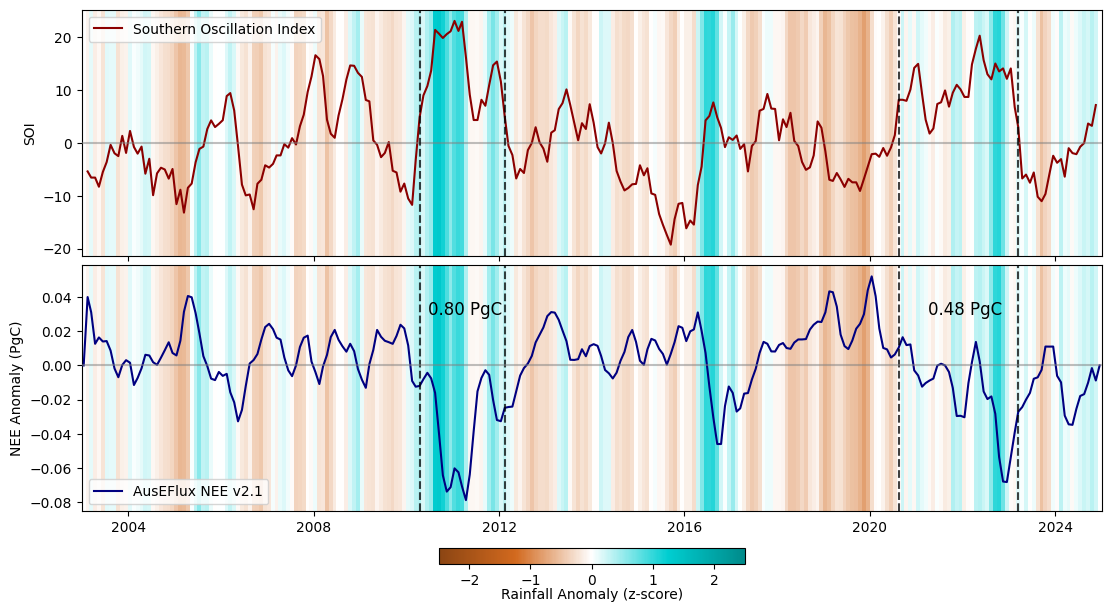

In [17]:
roll=3

rain_df = rain_std_anom.rename('rain').rolling(time=roll,
                min_periods=roll, center=True).mean().mean(['latitude', 'longitude']).sel(time=slice('2003', '2024')).to_dataframe().drop(['spatial_ref', 'month'], axis=1)

# plt.style.use('default')
# with plt.style.context('ggplot'):
fig, ax = plt.subplots(2,1, figsize=(11,6), sharex=True, layout='constrained')
ax2 = ax[1].twinx()
ax3 = ax[0].twinx()


soi.plot(ax=ax[0], label='Southern Oscillation Index',  c='darkred')
ax[0].axhline(0, c='grey', linestyle='-', alpha=0.5)
# ax[0].grid(alpha=0.5)
ax[0].set_xlabel(None);
ax[0].set_ylabel('SOI')
ax[0].margins(x=0)
ax[0].legend()
ax[0].set_frame_on(False)
ax[0].axvline(pd.to_datetime(nina_2020_time[0], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)
ax[0].axvline(pd.to_datetime(nina_2020_time[1], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)
ax[0].axvline(pd.to_datetime(nina_2011_time[0], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)
ax[0].axvline(pd.to_datetime(nina_2011_time[1], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)

# Plot rainfall bars
norm=plt.Normalize(-2.5,2.5)
cmap = mpl.colors.LinearSegmentedColormap.from_list("", ['saddlebrown','chocolate','white','darkturquoise','darkcyan'], N=256)
bar = ax3.bar(rain_df.index, 1, color=cmap(norm(rain_df['rain'])), width=32)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax3.set_zorder(ax[0].get_zorder()-1)
ax3.margins(x=0)
ax3.set_ylabel('')
ax3.set_yticks([])
ax3.set_ylim([0, 1]) 

##--------------------------------------------

nee_anom.drop('month').rolling(time=roll, min_periods=roll, center=True).mean().sum(['x','y']).plot(ax=ax[1], label='AusEFlux NEE v2.1', c='navy')
# (nee_anom+fire).drop('month').rolling(time=roll, min_periods=roll, center=True).mean().sum(['x','y']).plot(ax=ax[1], label='NEE+fire v2.1', c='navy')

ax[1].axvline(pd.to_datetime(nina_2020_time[0], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)
ax[1].axvline(pd.to_datetime(nina_2020_time[1], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)
ax[1].axvline(pd.to_datetime(nina_2011_time[0], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)
ax[1].axvline(pd.to_datetime(nina_2011_time[1], format='%Y-%m-%d'), c='k', linestyle='--', alpha=0.75)

ax[1].set_frame_on(False)
ax[1].axhline(0, c='grey', linestyle='-', alpha=0.5)
ax[1].margins(x=0)
ax[1].legend()
ax[1].set_title(None)
ax[1].set_ylabel('NEE Anomaly (PgC)')
ax[1].set_xlabel('')
ax[1].text(.34, .80, f"{np.abs(total_uptake_2011):.2f} PgC",
            transform=ax[1].transAxes, fontsize=12)

ax[1].text(.83, .80, f"{np.abs(total_uptake_2020):.2f} PgC",
            transform=ax[1].transAxes, fontsize=12)

# Plot rainfall bars
bar = ax2.bar(rain_df.index, 1, color=cmap(norm(rain_df['rain'])), width=32)
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax2, shrink=0.3, pad=0.05, location='bottom')
cbar.set_label('Rainfall Anomaly (z-score)',labelpad=.5)
ax2.set_zorder(ax[1].get_zorder()-1)
ax2.margins(x=0)
ax2.set_ylabel('')
ax2.set_yticks([])
ax2.set_ylim([0, 1]) ;

fig.savefig(f'{base}results/figs/LaNina_analysis.png',
                bbox_inches='tight', dpi=300)